# Testing game prediction results against Vegas odds with in sample data - Group Stages

## Objective

Test our class that predicts game results by comparing its results to Vegas lines before the games. It is important to take this with a grain of salt as this uses in sample testing.

Why separate group stage? Our model predicts on pre tournament data, hence extracting Vegas odds before world cups start makes it a more reaosnable comparison. Odds are usuallly posted when a games is officially gonna happen o knockout stage Vegas odd include group stage data, our model doesn't.

## Imports

In [21]:
import pandas as pd
from Class import PredictGame
from scipy.stats import poisson
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

In [22]:
os.getcwd()

'/Users/eialnisman/Desktop/WC2026Forecast'

In [23]:
os.chdir('/Users/eialnisman/Desktop/WC2026Forecast/')

## Test Data

In [24]:
class_test_data = pd.read_csv("1.DataCleaning-R/Data/CSV/ClassTestData.csv", parse_dates=["match_date"])
class_test_data = class_test_data.sort_values("match_id")
predict_data = class_test_data[[
    'home_team',
    'away_team',
    'home_ELO',
    'away_ELO',
    'home_prior_world_cups_coached',
    'away_prior_world_cups_coached',
    'home_players_with_multiple_prior_wcs',
    'away_players_with_multiple_prior_wcs',
    'home_avg_age',
    'away_avg_age',
    'home_distance_from_host_km',
    'away_distance_from_host_km',
    'stage_name',
    'match_date'
]]

## Vegas odds

In [25]:
GameResults = pd.read_csv("1.DataCleaning-R/Data/CSV/WorldCup_GroupStage_ResultOdds_2010_2026.csv")
GameScores = pd.read_csv("1.DataCleaning-R/Data/CSV/WorldCup_GroupStage_ScoreOdds_2010_2026.csv")

## Compare Group Games results

In [26]:
group_games = predict_data[predict_data["stage_name"] == "group stage"]
group_games = group_games.drop(columns=["stage_name"])

In [27]:
group_games = group_games.reset_index(drop=True)
group_games

,home_team,away_team,home_ELO,away_ELO,home_prior_world_cups_coached,away_prior_world_cups_coached,home_players_with_multiple_prior_wcs,away_players_with_multiple_prior_wcs,home_avg_age,away_avg_age,home_distance_from_host_km,away_distance_from_host_km,match_date
0,Mexico,South Africa,1890,1519,1,5,3,0,27.572603,27.313996,14740.229473,0.000000,2010-06-11
1,France,Uruguay,1890,1814,1,1,1,0,28.062537,27.084812,8702.227583,7547.521226,2010-06-11
2,Greece,South Korea,1782,1749,0,0,0,5,28.087671,27.583204,7546.786003,12926.215229,2010-06-12
3,Argentina,Nigeria,1897,1747,0,2,1,1,27.619655,26.250268,8219.664442,4644.837202,2010-06-12
4,England,United States,1985,1802,0,0,2,2,28.933889,27.273734,9398.536286,14937.120697,2010-06-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,Japan,Spain,1760,2036,0,0,3,3,28.242466,25.856270,8198.335941,5402.900900,2022-12-01
188,Ghana,Uruguay,1600,1847,0,0,1,7,25.295996,28.309589,5852.248444,13033.931859,2022-12-02
189,Portugal,South Korea,1972,1788,2,1,4,2,27.324974,28.171338,5684.568521,7210.452880,2022-12-02
190,Brazil,Cameroon,2149,1607,1,0,3,3,28.432561,26.805479,11937.552341,4665.891900,2022-12-02


In [28]:
GameResults[GameResults["year"]<2026]

,match_id,year,group,match_date,time,home_team,away_team,home_goals,away_goals,actual_score,...,home_pct_no_vig,draw_pct_no_vig,away_pct_no_vig,odds_provider,source_timing,source_url,tournament_first_game_date,requested_snapshot_date,scrape_date,odds_are_exact_requested_snapshot
0,2010_2010-06-11_SouthAfrica_Mexico,2010,A,2010-06-11,16:00,South Africa,Mexico,1.0,1.0,1-1,...,31.6566,30.7663,37.5771,CheckBestOdds best odds,archive last highest odds; not a one-week hist...,https://checkbestodds.com/football-odds/archiv...,2010-06-11,2010-06-04,2026-06-03,False
1,2010_2010-06-11_Uruguay_France,2010,A,2010-06-11,20:30,Uruguay,France,0.0,0.0,0-0,...,26.3110,30.4221,43.2669,CheckBestOdds best odds,archive last highest odds; not a one-week hist...,https://checkbestodds.com/football-odds/archiv...,2010-06-11,2010-06-04,2026-06-03,False
2,2010_2010-06-12_SouthKorea_Greece,2010,B,2010-06-12,13:30,South Korea,Greece,2.0,0.0,2-0,...,35.8464,31.2945,32.8592,CheckBestOdds best odds,archive last highest odds; not a one-week hist...,https://checkbestodds.com/football-odds/archiv...,2010-06-11,2010-06-04,2026-06-03,False
3,2010_2010-06-12_Argentina_Nigeria,2010,B,2010-06-12,16:00,Argentina,Nigeria,1.0,0.0,1-0,...,69.0744,20.9098,10.0158,CheckBestOdds best odds,archive last highest odds; not a one-week hist...,https://checkbestodds.com/football-odds/archiv...,2010-06-11,2010-06-04,2026-06-03,False
4,2010_2010-06-12_England_USA,2010,C,2010-06-12,20:30,England,USA,1.0,1.0,1-1,...,63.3494,23.4739,13.1767,CheckBestOdds best odds,archive last highest odds; not a one-week hist...,https://checkbestodds.com/football-odds/archiv...,2010-06-11,2010-06-04,2026-06-03,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,2022_2022-12-01_Japan_Spain,2022,NaN,2022-12-01,19:00:00,Japan,Spain,2.0,1.0,2-1,...,13.5402,21.7266,64.7332,Football-Data market average odds,Football-Data average odds; public workbook do...,https://www.football-data.co.uk/data,2022-11-20,2022-11-13,2026-06-03,False
188,2022_2022-12-02_Ghana_Uruguay,2022,NaN,2022-12-02,15:00:00,Ghana,Uruguay,0.0,2.0,0-2,...,20.9619,25.3897,53.6483,Football-Data market average odds,Football-Data average odds; public workbook do...,https://www.football-data.co.uk/data,2022-11-20,2022-11-13,2026-06-03,False
189,2022_2022-12-02_SouthKorea_Portugal,2022,NaN,2022-12-02,15:00:00,South Korea,Portugal,2.0,1.0,2-1,...,22.3485,25.4641,52.1874,Football-Data market average odds,Football-Data average odds; public workbook do...,https://www.football-data.co.uk/data,2022-11-20,2022-11-13,2026-06-03,False
190,2022_2022-12-02_Cameroon_Brazil,2022,NaN,2022-12-02,19:00:00,Cameroon,Brazil,1.0,0.0,1-0,...,10.5778,18.2410,71.1812,Football-Data market average odds,Football-Data average odds; public workbook do...,https://www.football-data.co.uk/data,2022-11-20,2022-11-13,2026-06-03,False


In [29]:
GameScores.columns

Index(['match_id', 'year', 'group', 'match_date', 'home_team', 'away_team',
       'score', 'home_goals', 'away_goals', 'score_probability_pct',
       'fitted_home_lambda', 'fitted_away_lambda', 'source_type',
       'odds_provider', 'source_url', 'source_timing'],
      dtype='object')

We can seehome and away don't always match in between datasets. Let's fix this.

In [30]:
model_teams = set(group_games["home_team"]).union(group_games["away_team"])
odds_teams = set(GameResults["home_team"]).union(GameResults["away_team"])

print(model_teams - odds_teams)
print(odds_teams - model_teams)

{'United States'}
{'Congo DR', 'Uzbekistan', 'Haiti', 'Cape Verde', 'Iraq', 'Austria', 'Curacao', 'Bosnia & Herzegovina', 'Czechia', 'USA', 'Jordan', 'Turkiye', 'Scotland', 'IR Iran', 'Korea Republic', 'Norway'}


In [31]:
name_map = {
    "United States": "USA",
    "Bosnia and Herzegovina": "Bosnia & Herzegovina"
}

for col in ["home_team", "away_team"]:
    group_games[col] = group_games[col].replace(name_map)

In [32]:
model_teams = set(group_games["home_team"]).union(group_games["away_team"])
odds_teams = set(GameResults["home_team"]).union(GameResults["away_team"])

print(model_teams - odds_teams)
print(odds_teams - model_teams)


set()
{'Congo DR', 'Uzbekistan', 'Haiti', 'Cape Verde', 'Iraq', 'Austria', 'Curacao', 'Bosnia and Herzegovina', 'Czechia', 'Jordan', 'Turkiye', 'Scotland', 'IR Iran', 'Korea Republic', 'Norway'}


In [33]:
group_games_join = group_games.copy()
odds_join = GameResults.copy()

group_games_join["match_date"] = pd.to_datetime(group_games_join["match_date"]).dt.date
odds_join["match_date"] = pd.to_datetime(odds_join["match_date"]).dt.date

group_games_join["team_1"] = group_games_join[["home_team", "away_team"]].min(axis=1)
group_games_join["team_2"] = group_games_join[["home_team", "away_team"]].max(axis=1)

odds_join["team_1"] = odds_join[["home_team", "away_team"]].min(axis=1)
odds_join["team_2"] = odds_join[["home_team", "away_team"]].max(axis=1)

merged = group_games_join.merge(
    odds_join,
    how="left",
    on=["team_1", "team_2", "match_date"],
    suffixes=("_model", "_vegas")
)

merged["vegas_swapped"] = merged["home_team_model"] != merged["home_team_vegas"]

merged["vegas_home_prob_aligned"] = np.where(
    merged["vegas_swapped"],
    merged["away_pct_no_vig"],
    merged["home_pct_no_vig"]
)

merged["vegas_away_prob_aligned"] = np.where(
    merged["vegas_swapped"],
    merged["home_pct_no_vig"],
    merged["away_pct_no_vig"]
)

merged["vegas_draw_prob_aligned"] = merged["draw_pct_no_vig"]

unmatched = merged[merged["home_team_vegas"].isna()]

print("Total group games:", len(group_games_join))
print("Matched games:", len(merged) - len(unmatched))
print("Unmatched games:", len(unmatched))

unmatched[["home_team_model", "away_team_model", "match_date"]].head(20)

Total group games: 192
Matched games: 191
Unmatched games: 1


,home_team_model,away_team_model,match_date
55,Ivory Coast,Japan,2014-06-14


In [34]:
merged = merged.dropna(subset=["vegas_home_prob_aligned"])
print(len(merged))

189


In [35]:
results = []

for _, row in merged.iterrows():

    game = PredictGame(
        row["home_team_model"],
        row["away_team_model"],
        row["home_ELO"],
        row["away_ELO"],
        row["home_prior_world_cups_coached"],
        row["away_prior_world_cups_coached"],
        row["home_players_with_multiple_prior_wcs"],
        row["away_players_with_multiple_prior_wcs"],
        row["home_avg_age"],
        row["away_avg_age"],
        row["home_distance_from_host_km"],
        row["away_distance_from_host_km"]
    )

    pred = game.WinnerPrediction()

    # Convert model output to one clean row
    pred = pred.iloc[0]

    # Determine true result
    if row["home_goals"] > row["away_goals"]:
        actual_result = "Home"
        model_prob = pred["Home"]
        vegas_prob = row["vegas_home_prob_aligned"]

    elif row["away_goals"] > row["home_goals"]:
        actual_result = "Away"
        model_prob = pred["Away"]
        vegas_prob = row["vegas_away_prob_aligned"]

    else:
        actual_result = "Tie"
        model_prob = pred["Tie"]
        vegas_prob = row["vegas_draw_prob_aligned"]

    # If Vegas probabilities are in percentages, convert to decimals
    if vegas_prob > 1:
        vegas_prob = vegas_prob / 100

    # If model probabilities are in percentages, convert to decimals
    if model_prob > 1:
        model_prob = model_prob / 100

    model_error = abs(1 - model_prob)
    vegas_error = abs(1 - vegas_prob)

    results.append({
        "year": row["year"],
        "home_team": row["home_team_model"],
        "away_team": row["away_team_model"],
        "actual_result": actual_result,
        "model_prob_actual": model_prob,
        "vegas_prob_actual": vegas_prob,
        "model_error": model_error,
        "vegas_error": vegas_error,
        "difference_model_minus_vegas": model_prob - vegas_prob,
        "abs_difference": abs(model_prob - vegas_prob),
        "better": "Model" if model_error < vegas_error else "Vegas"
    })

comparison_results = pd.DataFrame(results)

print("Average model probability assigned to true result:",
      comparison_results["model_prob_actual"].mean())

print("Average Vegas probability assigned to true result:",
      comparison_results["vegas_prob_actual"].mean())

print("Average difference, model minus Vegas:",
      comparison_results["difference_model_minus_vegas"].mean())

print("Average absolute difference:",
      comparison_results["abs_difference"].mean())

print("\nWho did better more often?")
print(comparison_results["better"].value_counts())

comparison_results["model_edge"] = (
    comparison_results["model_prob_actual"] 
    - comparison_results["vegas_prob_actual"]
)

model_won_most = comparison_results.sort_values(
    "model_edge", ascending=False
).head(5)

vegas_won_most = comparison_results.sort_values(
    "model_edge", ascending=True
).head(5)

print("Top 5 games where MODEL beat Vegas the most:")
display(
    model_won_most[[
        "year", "home_team", "away_team", "actual_result",
        "model_prob_actual", "vegas_prob_actual", "model_edge"
    ]]
)

print("Top 5 games where VEGAS beat Model the most:")
display(
    vegas_won_most[[
        "year", "home_team", "away_team", "actual_result",
        "model_prob_actual", "vegas_prob_actual", "model_edge"
    ]]
)

Average model probability assigned to true result: 0.35962962962962963
Average Vegas probability assigned to true result: 0.35664532804232807
Average difference, model minus Vegas: 0.0029843015873015845
Average absolute difference: 0.07752800529100529

Who did better more often?
better
Model    105
Vegas     84
Name: count, dtype: int64
Top 5 games where MODEL beat Vegas the most:


,year,home_team,away_team,actual_result,model_prob_actual,vegas_prob_actual,model_edge
120,2018.0,Mexico,South Korea,Away,0.471,0.175225,0.295775
178,2022.0,France,Tunisia,Home,0.831,0.588839,0.242161
115,2018.0,Argentina,Croatia,Away,0.482,0.240426,0.241574
134,2018.0,Mexico,Sweden,Away,0.507,0.276251,0.230749
132,2018.0,Argentina,Nigeria,Away,0.375,0.164209,0.210791


Top 5 games where VEGAS beat Model the most:


,year,home_team,away_team,actual_result,model_prob_actual,vegas_prob_actual,model_edge
55,2014.0,Argentina,Bosnia & Herzegovina,Home,0.459,0.733385,-0.274385
112,2018.0,Iran,Spain,Away,0.535,0.805164,-0.270164
174,2022.0,Netherlands,Qatar,Home,0.583,0.796055,-0.213055
63,2014.0,Chile,Spain,Away,0.400,0.610168,-0.210168
51,2014.0,Costa Rica,Uruguay,Away,0.459,0.665556,-0.206556


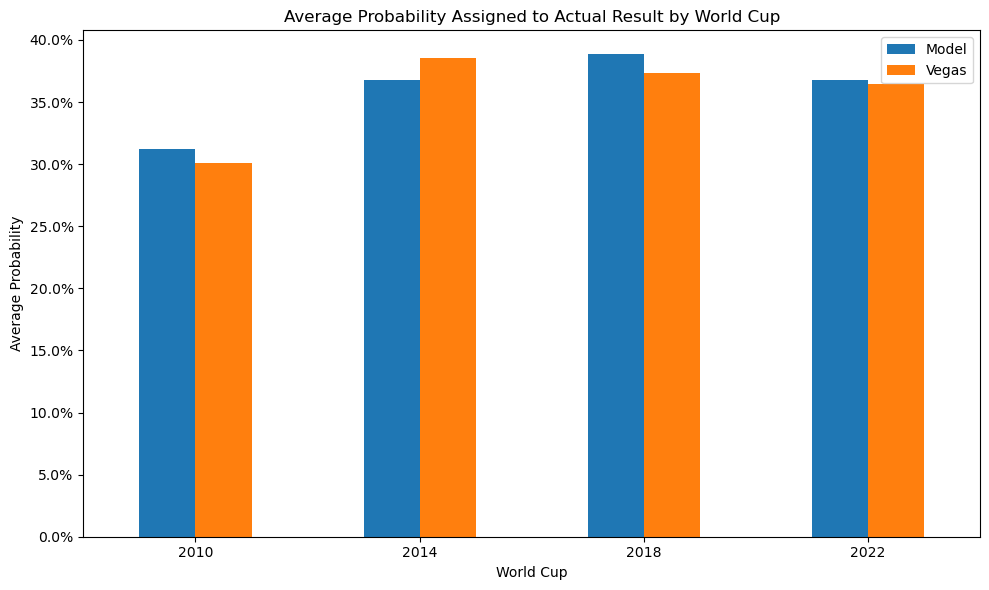

In [36]:
from matplotlib.ticker import PercentFormatter

year_summary = comparison_results.groupby("year").agg(
    model_avg_prob_actual=("model_prob_actual", "mean"),
    vegas_avg_prob_actual=("vegas_prob_actual", "mean")
).reset_index()

# Convert 2014.0 -> 2014
year_summary["year"] = year_summary["year"].astype(int)

ax = year_summary.plot(
    x="year",
    y=["model_avg_prob_actual", "vegas_avg_prob_actual"],
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Average Probability Assigned to Actual Result by World Cup")
ax.set_xlabel("World Cup")
ax.set_ylabel("Average Probability")

# Show percentages
ax.yaxis.set_major_formatter(PercentFormatter(1))

# Keep years clean
plt.xticks(rotation=0)

plt.legend(["Model", "Vegas"])
plt.tight_layout()
plt.show()

This is great news, our model tends to predict the winners and ties more effectively than Vegas for most world cups! It is important to note, this does **not** mean our model is "better" than sportsbooks. Thbere are a few reasons for this:
- We're testing omn data our model was trained on, although we tested extensively for overfitting it is still likely that our model detected some trends that weren't detectable before the actual games.
- Bookies dont always aim for the result that maximizes probability assigned to the actual score. They are also concerned with risk management, protofolio balance, customer engagement, and many more.

Anyways this is strong evidence that our model is detecting real trends that truly affect world cup results!

## Compare group game scores

In [37]:
model_games = group_games.copy()
score_odds = GameScores.copy()

# Fix names
name_map = {
    "United States": "USA",
    "Bosnia and Herzegovina": "Bosnia & Herzegovina"
}

for col in ["home_team", "away_team"]:
    model_games[col] = model_games[col].replace(name_map)
    score_odds[col] = score_odds[col].replace(name_map)

# Dates
model_games["match_date"] = pd.to_datetime(model_games["match_date"]).dt.date
score_odds["match_date"] = pd.to_datetime(score_odds["match_date"]).dt.date

# Order-independent game key
model_games["team_1"] = model_games[["home_team", "away_team"]].min(axis=1)
model_games["team_2"] = model_games[["home_team", "away_team"]].max(axis=1)

score_odds["team_1"] = score_odds[["home_team", "away_team"]].min(axis=1)
score_odds["team_2"] = score_odds[["home_team", "away_team"]].max(axis=1)

# Merge
merged_scores = model_games.merge(
    score_odds,
    how="left",
    on=["team_1", "team_2", "match_date"],
    suffixes=("_model", "_score")
)

In [38]:
merged_scores.columns.tolist()

['home_team_model',
 'away_team_model',
 'home_ELO',
 'away_ELO',
 'home_prior_world_cups_coached',
 'away_prior_world_cups_coached',
 'home_players_with_multiple_prior_wcs',
 'away_players_with_multiple_prior_wcs',
 'home_avg_age',
 'away_avg_age',
 'home_distance_from_host_km',
 'away_distance_from_host_km',
 'match_date',
 'team_1',
 'team_2',
 'match_id',
 'year',
 'group',
 'home_team_score',
 'away_team_score',
 'score',
 'home_goals',
 'away_goals',
 'score_probability_pct',
 'fitted_home_lambda',
 'fitted_away_lambda',
 'source_type',
 'odds_provider',
 'source_url',
 'source_timing']

In [39]:
# Drop rows where the score-odds merge failed
merged_scores = merged_scores.dropna(
    subset=["home_team_score", "away_team_score", "score", "score_probability_pct"]
).copy()

# Keep only valid score strings like "0-0", "1-2", "5-3"
merged_scores = merged_scores[
    merged_scores["score"].astype(str).str.match(r"^\d+-\d+$", na=False)
].copy()

# Bring in actual match results from the earlier GameResults merge
actual_results_lookup = merged[[
    "home_team_model",
    "away_team_model",
    "match_date",
    "home_goals",
    "away_goals"
]].copy()

actual_results_lookup = actual_results_lookup.rename(columns={
    "home_goals": "actual_home_goals",
    "away_goals": "actual_away_goals"
})

# Merge actual results onto the score-odds dataframe
merged_scores = merged_scores.merge(
    actual_results_lookup,
    how="left",
    on=["home_team_model", "away_team_model", "match_date"]
)

# Drop rows where actual result did not merge
merged_scores = merged_scores.dropna(
    subset=["actual_home_goals", "actual_away_goals"]
).copy()

# Create actual score in model home/away order
merged_scores["actual_score_model"] = (
    merged_scores["actual_home_goals"].astype(int).astype(str)
    + "-"
    + merged_scores["actual_away_goals"].astype(int).astype(str)
)

# Check whether GameScores has teams flipped relative to group_games
merged_scores["score_swapped"] = (
    merged_scores["home_team_model"] != merged_scores["home_team_score"]
)

# Function to flip score, for example 2-1 becomes 1-2
def flip_score(score):
    h, a = str(score).split("-")
    return f"{a}-{h}"

# Align score to model home/away order
merged_scores["score_aligned"] = np.where(
    merged_scores["score_swapped"],
    merged_scores["score"].apply(flip_score),
    merged_scores["score"]
)

# Keep only the row for the actual score
actual_score_rows = merged_scores[
    merged_scores["score_aligned"] == merged_scores["actual_score_model"]
].copy()

print("Rows:", len(actual_score_rows))
print("Unique matches:", actual_score_rows["match_id"].nunique())

Rows: 185
Unique matches: 185


In [40]:
merged_scores[[
    "home_team_model",
    "away_team_model",
    "home_team_score",
    "away_team_score",
    "actual_score_model",
    "score",
    "score_aligned",
    "score_probability_pct"
]].sample(10)

,home_team_model,away_team_model,home_team_score,away_team_score,actual_score_model,score,score_aligned,score_probability_pct
1078,Honduras,Spain,Spain,Honduras,2-0,5-4,4-5,0.0042
3535,Argentina,Iceland,Argentina,Iceland,1-1,1-1,1-1,8.3328
5997,Belgium,Morocco,Belgium,Morocco,0-2,3-3,3-3,0.3697
878,Paraguay,Slovakia,Slovakia,Paraguay,0-2,2-2,2-2,3.2956
1781,Australia,Chile,Chile,Australia,3-1,2-5,5-2,0.0074
1746,Netherlands,Spain,Spain,Netherlands,1-5,3-0,0-3,5.1639
3197,Ecuador,France,Ecuador,France,0-0,4-5,4-5,0.0193
5176,Netherlands,Senegal,Senegal,Netherlands,0-2,4-4,4-4,0.0185
6426,France,Tunisia,Tunisia,France,1-0,3-0,0-3,0.5769
1556,Brazil,Portugal,Portugal,Brazil,0-0,1-2,2-1,6.3586


In [41]:
actual_score_rows = merged_scores[
    merged_scores["score_aligned"] == merged_scores["actual_score_model"]
].copy()

print("Rows:", len(actual_score_rows))
print("Unique matches:", actual_score_rows["match_id"].nunique())

Rows: 185
Unique matches: 185


In [42]:
score_results = []

for _, row in actual_score_rows.iterrows():

    game = PredictGame(
        row["home_team_model"],
        row["away_team_model"],
        row["home_ELO"],
        row["away_ELO"],
        row["home_prior_world_cups_coached"],
        row["away_prior_world_cups_coached"],
        row["home_players_with_multiple_prior_wcs"],
        row["away_players_with_multiple_prior_wcs"],
        row["home_avg_age"],
        row["away_avg_age"],
        row["home_distance_from_host_km"],
        row["away_distance_from_host_km"]
    )

    pred_scores = game.ScorePredictions()

    actual_home_goals = int(row["home_goals"])
    actual_away_goals = int(row["away_goals"])

    model_match = pred_scores[
        (pred_scores["HomeGoals"] == actual_home_goals) &
        (pred_scores["AwayGoals"] == actual_away_goals)
    ]

    if len(model_match) == 0:
        model_prob = 0
    else:
        model_prob = model_match["Probability"].iloc[0]

    vegas_prob = row["score_probability_pct"]

    
    vegas_prob = vegas_prob / 100

    model_edge = model_prob - vegas_prob

    score_results.append({
        "year": row["year"],
        "home_team": row["home_team_model"],
        "away_team": row["away_team_model"],
        "actual_score": row["actual_score_model"],
        "model_prob_actual_score": model_prob,
        "vegas_prob_actual_score": vegas_prob,
        "model_edge": model_edge,
        "abs_difference": abs(model_edge),
        "better": "Model" if model_prob > vegas_prob else "Vegas"
    })

score_comparison_results = pd.DataFrame(score_results)

print("Average model probability assigned to actual score:",
      score_comparison_results["model_prob_actual_score"].mean())

print("Average Vegas probability assigned to actual score:",
      score_comparison_results["vegas_prob_actual_score"].mean())

print("Average difference, model minus Vegas:",
      score_comparison_results["model_edge"].mean())

print("Average absolute difference:",
      score_comparison_results["abs_difference"].mean())

print("\nWho assigned more probability more often?")
print(score_comparison_results["better"].value_counts())

print("\nTop 5 games where MODEL beat Vegas the most:")
display(
    score_comparison_results
    .sort_values("model_edge", ascending=False)
    .head(5)
)

print("\nTop 5 games where VEGAS beat Model the most:")
display(
    score_comparison_results
    .sort_values("model_edge", ascending=True)
    .head(5)
)

Average model probability assigned to actual score: 0.07788108108108108
Average Vegas probability assigned to actual score: 0.07712974594594595
Average difference, model minus Vegas: 0.0007513351351351344
Average absolute difference: 0.032704016216216214

Who assigned more probability more often?
better
Model    104
Vegas     81
Name: count, dtype: int64

Top 5 games where MODEL beat Vegas the most:


,year,home_team,away_team,actual_score,model_prob_actual_score,vegas_prob_actual_score,model_edge,abs_difference,better
28,2010.0,Honduras,Spain,2-0,0.147,0.003320,0.143680,0.143680,Model
8,2010.0,Denmark,Netherlands,2-0,0.120,0.018932,0.101068,0.101068,Model
21,2010.0,Japan,Netherlands,1-0,0.150,0.055891,0.094109,0.094109,Model
133,2018.0,Brazil,Serbia,0-2,0.110,0.018563,0.091437,0.091437,Model
175,2022.0,Argentina,Poland,0-2,0.105,0.016021,0.088979,0.088979,Model



Top 5 games where VEGAS beat Model the most:


,year,home_team,away_team,actual_score,model_prob_actual_score,vegas_prob_actual_score,model_edge,abs_difference,better
128,2018.0,Denmark,France,0-0,0.078,0.221403,-0.143403,0.143403,Vegas
174,2022.0,France,Tunisia,1-0,0.019,0.160621,-0.141621,0.141621,Vegas
6,2010.0,Ghana,Serbia,0-1,0.043,0.165762,-0.122762,0.122762,Vegas
131,2018.0,Germany,South Korea,2-0,0.021,0.138431,-0.117431,0.117431,Vegas
161,2022.0,Costa Rica,Japan,0-1,0.060,0.164273,-0.104273,0.104273,Vegas


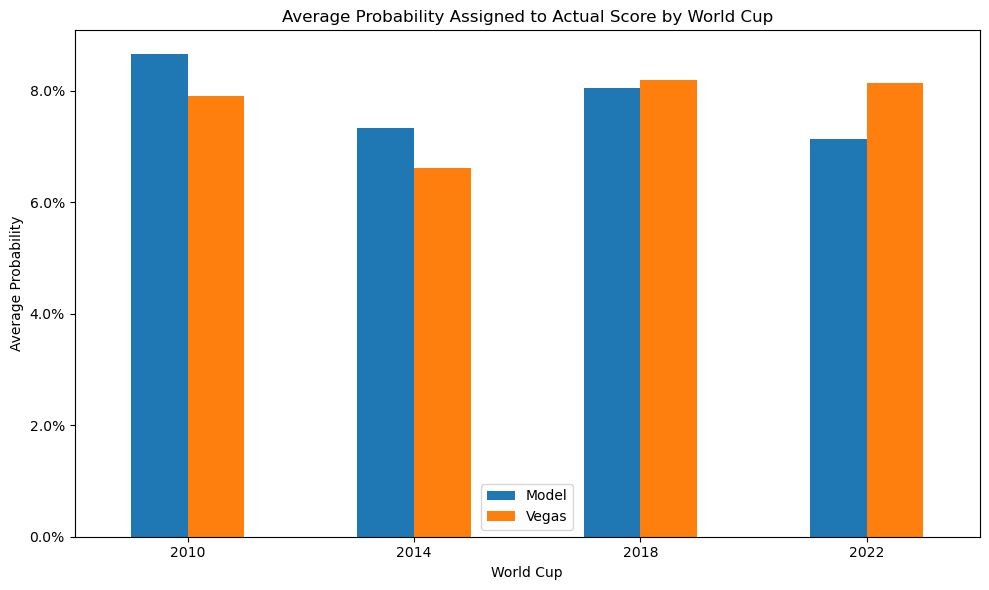

In [43]:
score_year_summary = score_comparison_results.groupby("year").agg(
    model_avg_prob_actual_score=("model_prob_actual_score", "mean"),
    vegas_avg_prob_actual_score=("vegas_prob_actual_score", "mean")
).reset_index()

score_year_summary["year"] = score_year_summary["year"].astype(int)

ax = score_year_summary.plot(
    x="year",
    y=["model_avg_prob_actual_score", "vegas_avg_prob_actual_score"],
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Average Probability Assigned to Actual Score by World Cup")
ax.set_xlabel("World Cup")
ax.set_ylabel("Average Probability")
ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.xticks(rotation=0)
plt.legend(["Model", "Vegas"])
plt.tight_layout()
plt.show()

Our model beats Vegas at predicting scores especially druing 2010 and 2014. It is likely that this is caused by trends that maybe were harder to observe in the data before 2014  and now looking in hindsight they're easier to detect. Regardless this is a good indicator of our model accuracy.